In [44]:
# Importing packages
import numpy as np
import matplotlib.pyplot as plt 
import os

# Setting up a plotting directory in the repository
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [45]:
""" Global parameters """

# Answer to the universe 
np.random.seed(42)

# Number of time periods
T = 1000

In [46]:
""" ARIMAX Hidden Markov Model Y_{t} = P*Y_{t-1} + b*X_{t} + e_{t} """

# Number of hidden states k
k = 2

# ARIMAX parameters rho (reliance on past time steps), 
# beta (weight of random variable X_{t}), and sigma (variance)
rho = np.array([0.2, 0.8])
beta = np.array([1.5, -0.5])
sigma = np.array([0.5, 1.0])

# Transition matrix P
P = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])

# Stochastic variable X
X = np.random.normal(loc=0, scale=1, size=T)

# Setting up states and time series value y
states = np.zeros(T, dtype=int)
y = np.zeros(T)

# Initial state and time series value chosen by random
states[0] = np.random.choice(k)
y[0] = np.random.normal(scale=sigma[states[0]])

# Looping through states across T time periods
for t in range(1, T):

    # State at time t in T and saving it to variable s
    states[t] = np.random.choice(k, p=P[states[t-1]])
    s = states[t]

    # Time series value depend on parameter rho times past value
    # plus beta times stochastic value X plus random noise
    y[t] = rho[s]*y[t-1] + beta[s]*X[t] + np.random.normal(scale=sigma[s])

    # Printing out every 100th step in the loop
    if t % 100 == 0:
        print(f"Time = {t:<5} State: {s:<3} X:{X[t]:>6.2f}  y:{y[t]:>6.2f}")



Time = 100   State: 0   X: -1.42  y: -1.73
Time = 200   State: 0   X:  0.36  y: -0.13
Time = 300   State: 0   X: -0.83  y: -0.93
Time = 400   State: 1   X: -1.59  y: -0.45
Time = 500   State: 0   X:  0.93  y:  1.63
Time = 600   State: 0   X:  0.76  y:  0.81
Time = 700   State: 1   X: -0.52  y: -1.34
Time = 800   State: 0   X:  0.94  y:  1.82
Time = 900   State: 1   X:  0.37  y: -2.79


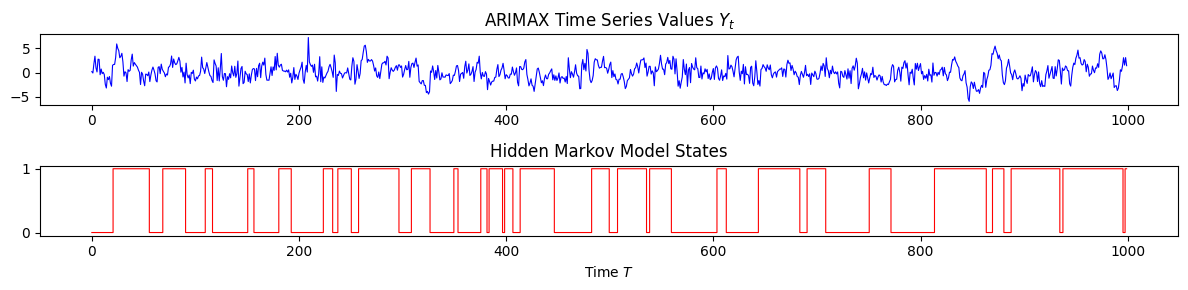

In [47]:
""" Plotting figure """

# Setting up an environment with two figures stacked
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 3))

# First panel showing the time series values over time
ax1.plot(y, color='blue', linewidth=0.8)
ax1.set_title("ARIMAX Time Series Values $Y_t$")

# Second panel showing the hidden states over time between 0 and 1
ax2.plot(states, color='red', drawstyle='steps-mid', linewidth=0.8)
ax2.set_title("Hidden Markov Model States")

# Arguments for both panels
plt.xlabel("Time $T$")

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(os.path.join(plot_dir, f"arimax-hmm.pdf"), bbox_inches="tight")
plt.show()